# **Image Captioning with EfficientNet-B4 and a Transformer Decoder**

**How to run:**
1. Open in Colab (`File → Upload notebook` or paste the GitHub link)
2. Enable GPU: `Runtime → Change runtime type → T4 GPU`
3. Upload your `caption_data.zip` when Cell 2 prompts, **or** place it at  
   `MyDrive/image_captioning/caption_data.zip` before mounting Drive
4. `Runtime → Run all`

---

### What this version is
This notebook implements an end-to-end image-captioning system trained on a 8000 image dataset. The model uses a pretrained EfficientNet-B4 convolutional neural network to extract visual features from each image and a Transformer decoder to generate a natural-language caption one word at a time. The notebook covers environment preparation, dataset processing, vocabulary construction, model design, training, evaluation, checkpoint management and inference.

The architecture is intentionally simplified for a relatively small dataset. Only the upper layers of EfficientNet-B4 are fine-tuned, a single visual feature map is used, and the decoder contains two Transformer layers. These choices reduce computational cost and help limit overfitting while preserving the main advantages of an encoder-decoder image-captioning system.

## 1 · Environment Setup

Detects whether we're on **Colab**, **Kaggle**, or **local**, sets PyTorch memory/env flags, and (on Colab) mounts Google Drive so models and checkpoints survive disconnects.

In [1]:
# ── Environment detection + initial setup 
import sys, os

# Detect runtime (must run before any google.colab import)
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

IN_KAGGLE = os.path.exists("/kaggle/input")
PLATFORM  = "colab" if IN_COLAB else ("kaggle" if IN_KAGGLE else "local")
print(f"Platform: {PLATFORM}")

# PyTorch memory allocator tweak (beneficial on CUDA)
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ── Google Drive mount (Colab only) 
DRIVE_DIR = None
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE_DIR = "/content/drive/MyDrive/image_captioning"
        os.makedirs(DRIVE_DIR, exist_ok=True)
        print(f"Drive mounted → models/checkpoints will be saved to {DRIVE_DIR}")
    except Exception as _e:
        print(f"Drive not mounted ({_e}). Models will be saved locally only.")


Platform: colab
Drive not mounted (Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.). Models will be saved locally only.


## 2 · Dataset Loading

Finds and unzips `caption_data` (images + captions) from the working directory, Google Drive, Kaggle input, or an interactive upload. After this cell `IMG_DIR` and `DATA_DIR` point at the data.

In [2]:
import zipfile
from pathlib import Path

# ── Path setup 
KAGGLE_INPUT = Path("/kaggle/input")
_kaggle_ds   = next(KAGGLE_INPUT.iterdir(), None) if KAGGLE_INPUT.exists() else None

DATA_DIR = Path("caption_data")
IMG_DIR  = DATA_DIR / "Images"


def _has_images(d):
    return d.exists() and len(list(d.glob("*.jpg"))) >= 100


def _has_captions(d):
    return (d / "captions.txt").exists() or (d / "captions").exists()


def _find_zip():
    candidates = [
        Path("caption_data.zip"),
        Path("/content/caption_data.zip"),
    ]
    if DRIVE_DIR:
        candidates.append(Path(DRIVE_DIR) / "caption_data.zip")
    if _kaggle_ds:
        candidates += list(_kaggle_ds.rglob("*.zip"))
    return next((p for p in candidates if p.exists()), None)


def _find_kaggle_images():
    if not KAGGLE_INPUT.exists():
        return None
    for jpg in KAGGLE_INPUT.rglob("*.jpg"):
        return jpg.parent
    return None


def _unzip(zip_path):
    print(f"Unzipping {zip_path}...")
    with zipfile.ZipFile(zip_path, "r") as z:
        names    = z.namelist()
        has_root = any(n.startswith("caption_data/") for n in names)
        if has_root:
            z.extractall(".")
        else:
            DATA_DIR.mkdir(exist_ok=True)
            z.extractall(str(DATA_DIR))
    if _has_images(IMG_DIR) and _has_captions(DATA_DIR):
        print(f"Done: {len(list(IMG_DIR.glob('*.jpg')))} images.")
    else:
        print("WARNING: unexpected layout:", [p.name for p in DATA_DIR.iterdir()][:10])


# ── Dataset resolution (Colab / Kaggle / local) 
if _has_images(IMG_DIR) and _has_captions(DATA_DIR):
    print(f"Dataset ready — {len(list(IMG_DIR.glob('*.jpg')))} images.")
elif (_kaggle_imgs := _find_kaggle_images()):
    IMG_DIR = _kaggle_imgs
    for _n in ["captions.txt", "captions"]:
        for _parent in [_kaggle_imgs.parent, _kaggle_imgs.parent.parent]:
            if (_parent / _n).exists():
                DATA_DIR = _parent
                break
    print(f"Kaggle input — IMG_DIR={IMG_DIR}  DATA_DIR={DATA_DIR}")
elif (zip_path := _find_zip()):
    _unzip(zip_path)
elif IN_COLAB:
    # Last resort: ask the user to upload caption_data.zip interactively
    print("No dataset found. Please select your caption_data.zip file:")
    from google.colab import files as _colab_files
    _uploaded = _colab_files.upload()
    if _uploaded:
        zip_path = Path(list(_uploaded.keys())[0])
        _unzip(zip_path)
    else:
        raise FileNotFoundError("Upload cancelled. Please provide caption_data.zip.")
else:
    raise FileNotFoundError(
        "No dataset found. Place caption_data.zip in the working directory "
        "or set DATA_DIR / IMG_DIR manually before continuing."
    )


Kaggle input — IMG_DIR=/kaggle/input/datasets/mariamromelashvili/caption-data/Images  DATA_DIR=/kaggle/input/datasets/mariamromelashvili/caption-data


## 3 · Imports & Hyperparameters

Imports libraries, picks the device, and defines **all training knobs**. Profile: **your Flickr8k data** (~8,091 images × 5 captions ≈ 40k rows) — no external dataset needed. Lighter regularisation than the over-tuned simplified run so the model can actually learn descriptive captions.

In [3]:
import os, re, json, math, random, pickle, time, gc
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as tvm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPUS = torch.cuda.device_count()
# USE_AMP gates all mixed-precision code; safe no-op on CPU
USE_AMP = DEVICE.type == "cuda"

# ── DataParallel vs single-GPU 
# FORCE_DP = False by default — single GPU with large batch is faster
# DataParallel gathers all gradients on GPU 0 during backward; GPU 1 sits idle.
#      Python scatter/gather adds ~10-20ms/step. For this 70M-param model,
#      1 GPU @ batch=64 beats 2 GPUs @ batch=32 with DP.
FORCE_DP = False          # was implicit True when N_GPUS>1 — set True to re-enable DP
USE_DP   = N_GPUS > 1 and FORCE_DP

# ── torch.compile (PyTorch ≥ 2.0) 
# fuses ops into optimised CUDA kernels (~20-40% faster).
# Requires fixed input shapes — collate_fn pads all captions to MAX_SEQ_LEN (Cell 7).
# If you still get InductorError, set USE_COMPILE = False (training still works).
USE_COMPILE = True        # set False if torch.compile crashes; SS epochs bypass compiled decoder

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print(f"Device: {DEVICE}  |  GPUs: {N_GPUS}  |  DataParallel: {USE_DP}  |  AMP: {USE_AMP}  |  compile: {USE_COMPILE}")

if "IMG_DIR" not in dir() or not Path(str(IMG_DIR)).exists():
    DATA_DIR = Path("caption_data")
    IMG_DIR  = DATA_DIR / "Images"

MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)

for _n in ["captions.txt", "captions"]:
    if (DATA_DIR / _n).exists():
        CAPS_FILE = DATA_DIR / _n
        break
else:
    raise FileNotFoundError(f"No captions file found in '{DATA_DIR}'.")
print(f"Captions: {CAPS_FILE}  |  Images: {IMG_DIR}")

# ── Hyper-parameters 
#  ~8,091 images x 5 captions = ~40,455 rows 
# No extra data required — this profile fits the data you already have.

# ── Model size 
PROJ_DIM = 512  
EMBED_SIZE = 512   
N_HEADS = 8     
N_LAYERS  = 2     # 2 layers — right-sized for 8k images x 5 captions
FFN_DIM  = 2048  

# ── Inference (beam search) 
BEAM_WIDTH = 5   
LENGTH_PENALTY = 0.7   

# ── Vocabulary 
MIN_FREQ = 2     
MAX_SEQ_LEN = 52    

# ── Batch size & training length 
BATCH_SIZE = 64 if USE_AMP else 32
NUM_EPOCHS = 30
PATIENCE = 8

# ── Learning rates 
ENCODER_LR      = 8e-5   
DECODER_LR      = 6e-4   
WARMUP_EPOCHS   = 3      
VAL_SPLIT       = 0.1    
MIXUP_ALPHA     = 0.2    
MAX_GRAD_NORM   = 3.0    

# ── Regularisation (lighter than the over-regularised run) ───────────────────
DROPOUT  = 0.15   
LABEL_SMOOTHING = 0.05   
WEIGHT_DECAY  = 0.01  
GRAD_ACCUM_STEPS = 1


# ── Checkpointing & evaluation
CKPT_EVERY = 5
EVAL_EVERY = 2 if IN_KAGGLE else 1
BLEU_EVAL_N = 200 if IN_KAGGLE else 400

print(f"Dataset profile: Flickr8k-full (~8k images x 5 captions, your own data)")
print(f"Batch size: {BATCH_SIZE}  |  Effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"Model: {N_LAYERS}-layer decoder  |  dropout={DROPOUT}  |  "
      f"label_smoothing={LABEL_SMOOTHING}  |  weight_decay={WEIGHT_DECAY}")
print(f"LR: encoder={ENCODER_LR}  decoder={DECODER_LR}  |  epochs={NUM_EPOCHS}  "
      f"|  early-stop patience={PATIENCE}")
print(f"BLEU eval: every {EVAL_EVERY} epoch(s), {BLEU_EVAL_N} images")


Device: cuda  |  GPUs: 2  |  DataParallel: False  |  AMP: True  |  compile: True
Captions: /kaggle/input/datasets/mariamromelashvili/caption-data/captions.txt  |  Images: /kaggle/input/datasets/mariamromelashvili/caption-data/Images
Dataset profile: Flickr8k-full (~8k images x 5 captions, your own data)
Batch size: 64  |  Effective batch: 64
Model: 2-layer decoder  |  dropout=0.15  |  label_smoothing=0.05  |  weight_decay=0.01
LR: encoder=8e-05  decoder=0.0006  |  epochs=30  |  early-stop patience=8
BLEU eval: every 2 epoch(s), 200 images


## 4 · Caption Loading & Cleaning

Parses the captions file (tab- or comma-separated), lowercases text and strips punctuation, and reports how many captions exist per image (a key signal for overfitting risk).

In [4]:
def load_captions(path):
    raw   = path.read_text(encoding="utf-8", errors="replace").strip()
    first = raw.split("\n")[0]
    if "\t" in first:
        rows = []
        for line in raw.split("\n"):
            line = line.strip()
            if not line or "\t" not in line: continue
            img_tag, cap = line.split("\t", 1)
            rows.append({"image": img_tag.split("#")[0].strip(), "caption": cap.strip()})
        return pd.DataFrame(rows)
    lines = raw.split("\n")
    start = 1 if lines[0].strip().lower().startswith("image") else 0
    rows  = []
    for line in lines[start:]:
        line = line.strip()
        if not line or "," not in line: continue
        img, cap = line.split(",", 1)
        rows.append({"image": img.strip().strip('"'), "caption": cap.strip().strip('"')})
    return pd.DataFrame(rows)[["image", "caption"]]


def clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z ]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


captions_df = load_captions(CAPS_FILE)
captions_df["caption"] = captions_df["caption"].apply(clean)
print(f"Rows: {len(captions_df):,}  |  Unique images: {captions_df['image'].nunique():,}")
captions_df.head(4)

_per_img = captions_df.groupby("image").size()
print(f"Captions per image — mean: {_per_img.mean():.2f}  min: {_per_img.min()}  max: {_per_img.max()}")
if _per_img.mean() >= 4.5:
    print("Good: ~5 captions per image (full Flickr8k-style). All captions "
          "are used in training — no extra data needed.")
elif _per_img.mean() < 2:
    print("WARNING: ~1 caption per image — captions will be weaker than full Flickr8k.")


Rows: 40,455  |  Unique images: 8,091
Captions per image — mean: 5.00  min: 5  max: 5
Good: ~5 captions per image (full Flickr8k-style). All captions are used in training — no extra data needed.


## 5 · Train / Validation Split

Splits **by image** (not by caption) so that all captions of a given image stay in one split — this prevents data leakage between train and validation.

In [5]:
all_images = captions_df["image"].unique().tolist()
random.shuffle(all_images)
n_val = int(len(all_images) * VAL_SPLIT)
val_images = set(all_images[:n_val])
train_df = captions_df[~captions_df["image"].isin(val_images)].reset_index(drop=True)
val_df = captions_df[ captions_df["image"].isin(val_images)].reset_index(drop=True)
print(f"Train: {train_df['image'].nunique():,} images  |  Val: {val_df['image'].nunique():,} images")


Train: 7,282 images  |  Val: 809 images


## 6 · Vocabulary

Builds the word<->index mapping from the training captions, keeping only words seen at least `MIN_FREQ` times. Adds the special tokens `<pad> <unk> <sos> <eos>` and saves `vocab.pkl`.

In [6]:
class Vocabulary:
    PAD, UNK, SOS, EOS = "<pad>", "<unk>", "<sos>", "<eos>"

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.stoi, self.itos = {}, {}

    def build(self, captions):
        cnt   = Counter(w for cap in captions for w in cap.split())
        words = [self.PAD, self.UNK, self.SOS, self.EOS] + [
            w for w, f in cnt.most_common() if f >= self.min_freq
        ]
        self.stoi = {w: i for i, w in enumerate(words)}
        self.itos = {i: w for w, i in self.stoi.items()}

    def __len__(self): return len(self.stoi)

    def encode(self, caption):
        unk = self.stoi[self.UNK]
        return ([self.stoi[self.SOS]]
                + [self.stoi.get(w, unk) for w in caption.split()]
                + [self.stoi[self.EOS]])

    def decode(self, ids, skip_special=True):
        sp = {self.PAD, self.UNK, self.SOS, self.EOS}
        return " ".join(
            self.itos[i] for i in ids
            if not skip_special or self.itos.get(i, self.UNK) not in sp
        )


vocab = Vocabulary(min_freq=MIN_FREQ)
vocab.build(train_df["caption"].tolist())
print(f"Vocab size: {len(vocab):,}")
with open(MODEL_DIR / "vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)


Vocab size: 4,902


## 7 · Transforms, Mixup & DataLoaders

Defines image augmentation (train) and plain resize/normalize (val), the **mixup** regulariser, the `Dataset`/`collate_fn` (captions padded to a fixed length), and the train/val `DataLoader`s.

In [7]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Transforms
train_transform = transforms.Compose([
    transforms.Resize(400, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomCrop(380),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.05),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
])

val_transform = transforms.Compose([
    transforms.Resize((380, 380), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


def mixup_batch(imgs, caps_padded, lengths, alpha=0.2):
    if alpha <= 0 or random.random() > 0.5:
        return imgs, caps_padded, lengths
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(imgs.size(0), device=imgs.device)
    imgs = lam * imgs + (1 - lam) * imgs[perm]
    if lam < 0.5:
        caps_padded = caps_padded[perm]
        # lengths must be on the same device as perm (run_epoch moves it to DEVICE)
        lengths = lengths.to(perm.device)[perm]
    return imgs, caps_padded, lengths


class CaptionDataset(Dataset):
    def __init__(self, df, img_dir, vocab, transform=None, max_len=52):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.vocab     = vocab
        self.transform = transform
        self.max_len   = max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row["image"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        ids = self.vocab.encode(row["caption"])[:self.max_len]
        return img, torch.tensor(ids, dtype=torch.long)


def collate_fn(batch):
    imgs, caps = zip(*batch)
    imgs    = torch.stack(imgs)
    lengths = [len(c) for c in caps]
    #  always pad to MAX_SEQ_LEN → every batch is (B, MAX_SEQ_LEN) — fixed shape.
    #  Decoder can use torch.compile(dynamic=False) safely (see Cell 10).
    padded  = torch.zeros(len(caps), MAX_SEQ_LEN, dtype=torch.long)
    for i, (c, l) in enumerate(zip(caps, lengths)):
        padded[i, :l] = c
    return imgs, padded, torch.tensor(lengths, dtype=torch.long)


# ── DataLoader settings 
_n_workers = min(4, os.cpu_count() or 2)
_dl_kwargs = dict(
    num_workers  = _n_workers,      
    pin_memory = USE_AMP,         
    persistent_workers = _n_workers > 0,   
    prefetch_factor = 2 if _n_workers > 0 else None,  
)
print(f"DataLoader workers: {_n_workers}")

train_loader = DataLoader(
    CaptionDataset(train_df, IMG_DIR, vocab, train_transform, MAX_SEQ_LEN),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, **_dl_kwargs,
)
val_loader = DataLoader(
    CaptionDataset(val_df, IMG_DIR, vocab, val_transform, MAX_SEQ_LEN),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, **_dl_kwargs,
)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

# Quick DataLoader benchmark
t0 = time.time()
for i, (imgs, caps, lengths) in enumerate(train_loader):
    if i == 9: break
elapsed = time.time() - t0
print(f"DataLoader: 10 batches in {elapsed:.2f}s  ({elapsed/10:.3f}s/batch)")


DataLoader workers: 4
Train batches: 569  |  Val batches: 64
DataLoader: 10 batches in 10.30s  (1.030s/batch)


## 8 · Sample Visualization

Sanity check: shows a few training images with their captions to confirm the data pipeline works.

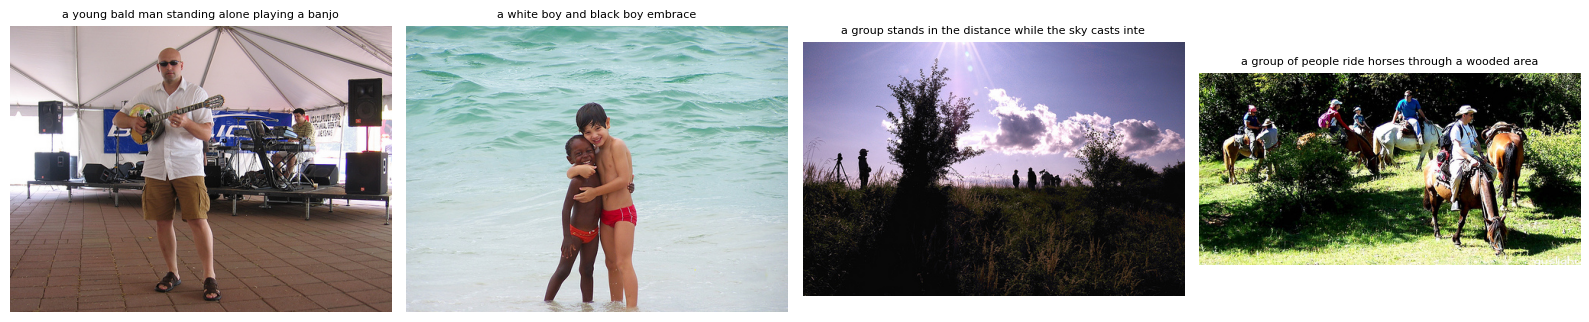

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, row) in zip(axes, train_df.sample(4, random_state=SEED).iterrows()):
    ax.imshow(Image.open(IMG_DIR / row["image"]).convert("RGB"))
    ax.set_title(row["caption"][:55], fontsize=8, wrap=True)
    ax.axis("off")
plt.tight_layout(); plt.show()


## 9 · Model Architecture

This cell defines the complete neural-network architecture.

EfficientNet-B4 image encoder

The EncoderCNN class loads EfficientNet-B4 with ImageNet-pretrained weights. Most of the convolutional backbone is frozen, while blocks 6, 7 and 8 remain trainable. Earlier EfficientNet layers already recognize general visual features such as edges, shapes and textures, while the upper layers can adapt to objects and scenes found in the captioning dataset.

The final EfficientNet feature map has 1,792 channels. A 1 × 1 convolution projects these channels into the lower-dimensional representation expected by the Transformer. The two-dimensional feature map is then flattened into a sequence of visual tokens. Each token represents a spatial region of the image.

Positional encoding

The PositionalEncoding class adds sinusoidal position information to word embeddings. Transformers do not inherently understand token order, so positional encoding allows the decoder to distinguish the first word from later words in a caption.

Transformer decoder layer

Each TransformerDecoderLayer contains:

masked self-attention over previously generated caption words;
cross-attention between caption tokens and visual image tokens;
a feed-forward neural network;
residual connections and layer normalization.

The causal attention mask prevents the decoder from seeing future words during training.

Caption decoder

CaptionDecoder converts caption token IDs into embeddings, adds positional information and processes them through multiple Transformer layers. The final linear layer produces one score for every vocabulary word at every caption position.

The word-embedding matrix and output-projection matrix share weights. This technique, known as weight tying, reduces the number of parameters and can improve language generation.

The class also implements beam-search generation. Instead of selecting only the highest-probability word at each step, beam search keeps several possible partial captions and returns the best complete sequence after applying a length penalty.

Expected output: this cell defines the architecture but does not train or display results yet.

In [9]:
# ============================================================================
# MODEL ARCHITECTURE  
# ----------------------------------------------------------------------------
# Encoder : EfficientNet-B4, only blocks 6-8 fine-tuned, SINGLE-scale features
# Decoder : 2-layer standard Transformer (self-attn + cross-attn), weight tying
# ============================================================================

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ENCODER  ·  EfficientNet-B4 (single-scale)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EncoderCNN(nn.Module):
    def __init__(self, proj_dim=512, dropout=0.1):
        super().__init__()
        try:
            base = tvm.efficientnet_b4(weights=tvm.EfficientNet_B4_Weights.IMAGENET1K_V1)
        except Exception as _e:
            _msg = str(_e).lower()
            if any(k in _msg for k in ("name resolution", "urlopen", "gaierror", "connection")):
                raise RuntimeError(
                    "\n\nCannot download EfficientNet-B4 weights — internet is disabled.\n"
                    "  Kaggle : right panel -> Settings -> Internet -> ON  (session will restart)\n"
                    "  Colab  : Runtime -> Change runtime type -> confirm, then re-run\n"
                    "After enabling internet, re-run all cells from the top.\n"
                ) from None
            raise
        self.features = base.features
        self.dropout  = nn.Dropout2d(dropout)

        # only blocks 6,7,8 — the top, most semantic layers.
        # fine-tuning 5 blocks on ~7k images overfits the encoder; lower
        # blocks already learned generic edges/textures from ImageNet.
        for p in self.features.parameters():
            p.requires_grad = False
        for blk_idx in [6, 7, 8]:
            for p in self.features[blk_idx].parameters():
                p.requires_grad = True

        self.proj_final = nn.Sequential(
            nn.Conv2d(1792, proj_dim, 1, bias=False),
            nn.BatchNorm2d(proj_dim), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # single pass through all blocks -> final feature map only -> (B, H*W, C)
        feat = self.features(x)
        feat = self.dropout(feat)
        f = self.proj_final(feat)
        B, C, H, W = f.shape
        return f.view(B, C, H * W).permute(0, 2, 1)   # (B, H*W, proj_dim)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DECODER  ·  Standard Transformer (no coverage)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        # dropout on the positional signal only (not on x + pe)
        return x + self.dropout(self.pe[:, :x.size(1)])


class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model), nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        sa, _ = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask,
                               key_padding_mask=tgt_key_padding_mask, need_weights=False)
        tgt = self.norm1(tgt + sa)
        ca, _ = self.cross_attn(tgt, memory, memory, need_weights=False)
        tgt = self.norm2(tgt + ca)
        tgt = self.norm3(tgt + self.ff(tgt))
        return tgt


class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, n_layers=2,
                 ffn_dim=2048, max_len=52, dropout=0.3):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc = PositionalEncoding(d_model, max_len + 2, dropout)
        self.layers  = nn.ModuleList([
            TransformerDecoderLayer(d_model, n_heads, ffn_dim, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.fc_out  = nn.Linear(d_model, vocab_size)
        self.d_model = d_model
        self.n_heads = n_heads
        nn.init.xavier_uniform_(self.embed.weight)
        # KEPT: weight tying — embedding and output projection share one matrix.
        # Cheap, and genuinely helps fluency / rare-word use on small datasets.
        self.fc_out.weight = self.embed.weight
        nn.init.zeros_(self.fc_out.bias)

    @staticmethod
    def _causal_mask(sz, device):
        return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()

    def forward(self, memory, captions):
        tgt_tokens = captions[:, :-1]
        tgt_emb = self.pos_enc(self.embed(tgt_tokens) * math.sqrt(self.d_model))
        T_tgt = tgt_emb.size(1)
        causal = self._causal_mask(T_tgt, memory.device)
        pad_mask = (tgt_tokens == 0)   # True = ignore (PyTorch MHA convention)
        h = tgt_emb
        for layer in self.layers:
            h = layer(h, memory, tgt_mask=causal, tgt_key_padding_mask=pad_mask)
        return self.fc_out(h)

    @torch.no_grad()
    def generate_beam(self, memory, vocab, beam_width=3, max_len=48, length_penalty=0.7):
        # DROPPED: coverage tensor threaded through each beam (no longer needed).
        # Length penalty is applied only when RANKING (raw log-probs accumulate).
        self.eval()
        sos = vocab.stoi[vocab.SOS]; eos = vocab.stoi[vocab.EOS]
        pad = vocab.stoi[vocab.PAD]; unk = vocab.stoi[vocab.UNK]
        device = memory.device

        def _norm(raw, length):
            return raw / (((5 + length) / 6) ** length_penalty)

        beams = [(0.0, [sos])]
        done  = []
        for _ in range(max_len):
            if not beams:
                break
            next_beams = []
            for score, tokens in beams:
                if tokens[-1] == eos:
                    done.append((score, tokens))
                    continue
                ids  = torch.tensor([tokens], dtype=torch.long, device=device)
                emb  = self.pos_enc(self.embed(ids) * math.sqrt(self.d_model))
                mask = self._causal_mask(emb.size(1), device)
                h = emb
                for layer in self.layers:
                    h = layer(h, memory, tgt_mask=mask)
                logits   = self.fc_out(h[:, -1, :])
                log_prob = F.log_softmax(logits, dim=-1).squeeze(0)
                top_lp, top_id = log_prob.topk(beam_width)
                for tlp, tid in zip(top_lp.tolist(), top_id.tolist()):
                    next_beams.append((score + tlp, tokens + [tid]))
            if not next_beams:
                break
            next_beams.sort(key=lambda x: _norm(x[0], len(x[1])), reverse=True)
            beams = next_beams[:beam_width]
        if not done:
            done = [(b[0], b[1]) for b in beams]
        _, best = max(done, key=lambda x: _norm(x[0], len(x[1])))
        skip = {sos, eos, pad, unk}
        return [vocab.itos[i] for i in best if i not in skip]


## 10 · Model Initialization

Instantiates the encoder + decoder, optionally wraps them in `torch.compile`, prints parameter counts, and runs a forward-pass shape check to catch errors before training.

In [10]:
_encoder = EncoderCNN(proj_dim=PROJ_DIM, dropout=DROPOUT).to(DEVICE)
_decoder = CaptionDecoder(
    vocab_size=len(vocab), d_model=EMBED_SIZE, n_heads=N_HEADS,
    n_layers=N_LAYERS, ffn_dim=FFN_DIM, max_len=MAX_SEQ_LEN, dropout=DROPOUT,
).to(DEVICE)

if USE_DP:
    encoder = nn.DataParallel(_encoder)
    decoder = nn.DataParallel(_decoder)
    print(f"DataParallel across {N_GPUS} GPUs")
else:
    encoder = _encoder
    decoder = _decoder
    print("Single-GPU mode")

# ── torch.compile
if USE_COMPILE:
    try:
        encoder = torch.compile(encoder, dynamic=False)
        decoder = torch.compile(decoder, dynamic=False)
        print("torch.compile: encoder + decoder both static (fixed shapes) — compiles once per phase")
    except Exception as _e:
        print(f"torch.compile skipped ({_e})")

enc_params = sum(p.numel() for p in _encoder.parameters())
dec_params = sum(p.numel() for p in _decoder.parameters())
print(f"Encoder: {enc_params:,}  |  Decoder: {dec_params:,}  |  Total: {enc_params+dec_params:,}")

with torch.no_grad():
    _check_bs = 2 * max(1, N_GPUS)
    _f = encoder(torch.zeros(_check_bs, 3, 380, 380).to(DEVICE))
    _l = decoder(_f, torch.zeros(_check_bs, 10, dtype=torch.long).to(DEVICE))
    print(f"Encoder out: {_f.shape}  |  Decoder out: {_l.shape}")
print("Shape check passed.")


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 102MB/s] 


Single-GPU mode
torch.compile: encoder + decoder both static (fixed shapes) — compiles once per phase
Encoder: 18,467,144  |  Decoder: 10,922,790  |  Total: 29,389,934


W0701 11:27:56.161000 58 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Encoder out: torch.Size([4, 144, 512])  |  Decoder out: torch.Size([4, 9, 4902])
Shape check passed.


## 11 · Loss, Optimizer & Scheduler

Cross-entropy loss with label smoothing, AdamW with **layer-wise LR decay** on the encoder and strong weight decay, mixed-precision `GradScaler`, and a warmup + cosine LR schedule.

In [11]:
pad_idx   = vocab.stoi[vocab.PAD]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=LABEL_SMOOTHING)


def _enc_param_groups(enc_module, base_lr, decay=0.65):
    groups = []
    for i, blk_idx in enumerate([8, 7, 6]):
        groups.append({"params": list(enc_module.features[blk_idx].parameters()),
                       "lr": base_lr * (decay ** i), "name": f"enc_block{blk_idx}"})
    groups.append({"params": list(enc_module.proj_final.parameters()),
                   "lr": base_lr, "name": "enc_proj"})
    return groups


_param_groups = (
    _enc_param_groups(_encoder, ENCODER_LR)
    + [{"params": _decoder.parameters(), "lr": DECODER_LR, "name": "decoder"}]
)

try:
    optimizer = optim.AdamW(_param_groups, weight_decay=WEIGHT_DECAY, fused=USE_AMP)
    if USE_AMP:
        print("Fused AdamW ✓")
except TypeError:
    optimizer = optim.AdamW(_param_groups, weight_decay=WEIGHT_DECAY)
    print("Standard AdamW (upgrade to PyTorch >= 2.0 for fused version)")

# torch.amp.GradScaler (PyTorch >= 2.4); fallback for older versions.
try:
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)
except (TypeError, RuntimeError):
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    p = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * p))


scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print("Optimiser ready")
print("Param groups:", [(g["name"], f"{g['lr']:.1e}") for g in optimizer.param_groups])


Fused AdamW ✓
Optimiser ready
Param groups: [('enc_block8', '2.7e-05'), ('enc_block7', '1.7e-05'), ('enc_block6', '1.1e-05'), ('enc_proj', '2.7e-05'), ('decoder', '2.0e-04')]


## 12 · BLEU Evaluation

A lightweight corpus-BLEU implementation and `evaluate_bleu`, which beam-decodes captions for a sample of validation images and scores them against the human references.

In [12]:
from collections import Counter as _C


def _ng(tok, n):
    return _C(tuple(tok[i:i+n]) for i in range(len(tok)-n+1))


def corpus_bleu(hyps, refs, max_n=4):
    out = {}
    for n in range(1, max_n+1):
        num = den = 0
        for h, rs in zip(hyps, refs):
            hng  = _ng(h, n)
            rmax = _C()
            for r in rs:
                for ng in (rng := _ng(r, n)):
                    rmax[ng] = max(rmax[ng], rng[ng])
            num += sum(min(c, rmax[ng]) for ng, c in hng.items())
            den += max(1, sum(hng.values()))
        out[f"bleu{n}"] = num / max(den, 1)
    return out


def evaluate_bleu(enc_module, dec_module, val_df, vocab, n=None):
    if n is None:
        n = BLEU_EVAL_N
    enc_module.eval(); dec_module.eval()
    imgs = val_df["image"].unique().tolist()
    random.shuffle(imgs); imgs = imgs[:n]
    hyps, refs = [], []
    with torch.no_grad():
        for idx, name in enumerate(imgs):
            t = val_transform(Image.open(IMG_DIR / name).convert("RGB")).unsqueeze(0).to(DEVICE)
            f = enc_module(t)
            hyps.append(dec_module.generate_beam(f, vocab, BEAM_WIDTH, length_penalty=LENGTH_PENALTY))
            refs.append([r.split() for r in val_df[val_df["image"]==name]["caption"].tolist()])
            # Flush VRAM cache every 50 images to prevent fragmentation on Kaggle 2×T4
            if USE_AMP and (idx + 1) % 50 == 0:
                torch.cuda.empty_cache()
    return corpus_bleu(hyps, refs)


## 13 · GPU / Forward-Pass Sanity Check

Confirms the model and a real batch are on the GPU and times one forward pass — a quick check that everything is wired up before the long training run.

In [13]:
import subprocess, time

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count:{torch.cuda.device_count()}")
print(f"DEVICE: {DEVICE}")
print(f"USE_AMP: {USE_AMP}")
print(f"USE_DP:{USE_DP}")
print()

enc_device = next(_encoder.parameters()).device
dec_device = next(_decoder.parameters()).device
print(f"_encoder is on: {enc_device}")
print(f"_decoder is on: {dec_device}")
print()

imgs, caps, lengths = next(iter(train_loader))
print(f"Batch imgs device before .to(): {imgs.device}")
imgs = imgs.to(DEVICE, non_blocking=True)
caps = caps.to(DEVICE, non_blocking=True)
print(f"Batch imgs device after  .to(): {imgs.device}")
print()

# BUG FIX: device_type must be dynamic, not hardcoded "cuda"
torch.cuda.synchronize() if USE_AMP else None
t0 = time.time()
with torch.no_grad(), torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
    feat   = encoder(imgs)
    logits = decoder(feat, caps)
if USE_AMP: torch.cuda.synchronize()
print(f"Forward pass: {time.time()-t0:.3f}s  (should be <0.5s on GPU)")
print()

result = subprocess.run(
    ["nvidia-smi", "--query-gpu=index,utilization.gpu,memory.used,memory.total",
     "--format=csv,noheader,nounits"],
    capture_output=True, text=True,
)
print("nvidia-smi (index, util%, mem_used, mem_total):")
print(result.stdout.strip() if result.returncode == 0 else "nvidia-smi not available")


CUDA available: True
Device count:2
DEVICE: cuda
USE_AMP: True
USE_DP:False

_encoder is on: cuda:0
_decoder is on: cuda:0

Batch imgs device before .to(): cpu
Batch imgs device after  .to(): cuda:0

Forward pass: 119.238s  (should be <0.5s on GPU)

nvidia-smi (index, util%, mem_used, mem_total):
0, 94, 461, 15360
1, 0, 3, 15360


## 14 · Resume From Checkpoint

Optional. After a disconnect, run this to auto-load the latest periodic checkpoint and restore `best_val` / `best_bleu4` so training continues where it left off. Skip it for a fresh run.

In [14]:

# RESUME CELL — run this if your Colab/Kaggle runtime disconnected    

import shutil

RESUME_EPOCH = None   # e.g. 15  to resume after epoch 15

def _find_latest_checkpoint():
    """Return epoch number of the most recent *_periodic checkpoint, or None."""
    candidates = []
    search_dirs = [MODEL_DIR]
    if DRIVE_DIR:
        search_dirs.append(Path(DRIVE_DIR))
    for d in search_dirs:
        for p in d.glob("encoder_epoch*_periodic.pth"):
            m = re.search(r"epoch(\d+)", p.stem)
            if m:
                candidates.append((int(m.group(1)), p.parent))
    if not candidates:
        return None, None
    ep, folder = max(candidates, key=lambda x: x[0])
    return ep, folder

def _find_checkpoint_folder(epoch):
    """Locate folder containing periodic checkpoint for *epoch*."""
    for d in [MODEL_DIR, Path(DRIVE_DIR)] if DRIVE_DIR else [MODEL_DIR]:
        if (d / f"encoder_epoch{epoch:02d}_periodic.pth").exists():
            return d
    return MODEL_DIR

def _load_checkpoint(epoch, folder):
    """Load encoder + decoder weights from *folder* for *epoch*."""
    enc_name = f"encoder_epoch{epoch:02d}_periodic.pth"
    dec_name = f"decoder_epoch{epoch:02d}_periodic.pth"
    for name, src_folder in [(enc_name, folder), (dec_name, folder)]:
        src = src_folder / name
        dst = MODEL_DIR / name
        if not dst.exists() and src.exists() and src != dst:
            shutil.copy(src, dst)
    _encoder.load_state_dict(
        torch.load(MODEL_DIR / enc_name, map_location=DEVICE, weights_only=True))
    _decoder.load_state_dict(
        torch.load(MODEL_DIR / dec_name, map_location=DEVICE, weights_only=True))
    print(f"Loaded checkpoint from epoch {epoch} ({folder})")

def _load_training_state():
    """Restore best_val / best_bleu4 / loss curves if training_state.json exists."""
    for d in [MODEL_DIR, Path(DRIVE_DIR)] if DRIVE_DIR else [MODEL_DIR]:
        p = d / "training_state.json"
        if p.exists():
            with open(p) as f:
                return json.load(f)
    return None

# ── Auto-detect or use specified epoch
_ckpt_folder = MODEL_DIR
if RESUME_EPOCH is None:
    RESUME_EPOCH, _ckpt_folder = _find_latest_checkpoint()
    if _ckpt_folder is None:
        _ckpt_folder = MODEL_DIR
else:
    _ckpt_folder = _find_checkpoint_folder(RESUME_EPOCH)

_ts = None
if RESUME_EPOCH is not None:
    _load_checkpoint(RESUME_EPOCH, _ckpt_folder)
    START_EPOCH = RESUME_EPOCH + 1
    for _ in range(RESUME_EPOCH):
        scheduler.step()
    print(f"Resuming training from epoch {START_EPOCH}/{NUM_EPOCHS}")
    print(f"Current LR — enc: {optimizer.param_groups[0]['lr']:.2e}  "
          f"dec: {optimizer.param_groups[-1]['lr']:.2e}")
    _ts = _load_training_state()
    if _ts:
        print(f"Found training_state.json: best_val={_ts.get('best_val', float('nan')):.4f}  "
              f"best_bleu4={_ts.get('best_bleu4', 0.0):.3f}")
else:
    START_EPOCH = 1
    print("No checkpoint found — starting from epoch 1")
    print("Tip: make sure Google Drive is mounted (Cell 1) so checkpoints survive disconnects.")


No checkpoint found — starting from epoch 1
Tip: make sure Google Drive is mounted (Cell 1) so checkpoints survive disconnects.


## 15 · Training Loop

Runs train + validation each epoch, evaluates BLEU, saves **two** checkpoints (best val loss and best BLEU-4), and uses **early stopping** to halt once validation stops improving — the main defence against late-epoch overfitting.

In [15]:
import shutil


def run_epoch(loader, train, epoch=0):
    encoder.train(train); decoder.train(train)
    tot, ntok = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    if train:
        optimizer.zero_grad(set_to_none=True)

    with ctx:
        for step, (imgs, caps, lengths) in enumerate(
            tqdm(loader, desc="train" if train else "val  ", leave=False)
        ):
            imgs = imgs.to(DEVICE, non_blocking=True)
            caps = caps.to(DEVICE, non_blocking=True)
            lengths = lengths.to(DEVICE, non_blocking=True)
            if train:
                imgs, caps, lengths = mixup_batch(imgs, caps, lengths, MIXUP_ALPHA)

            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                feat   = encoder(imgs)
                # DROPPED: ss_rate argument + torch.compile bypass for SS.
                logits = decoder(feat, caps)  # lengths not needed (no scheduled sampling)
                tgt    = caps[:, 1:]
                loss   = criterion(logits.reshape(-1, len(vocab)), tgt.reshape(-1))
                if GRAD_ACCUM_STEPS > 1:
                    loss = loss / GRAD_ACCUM_STEPS

            if train:
                scaler.scale(loss).backward()
                is_last_step = (step == len(loader) - 1)
                if (step + 1) % GRAD_ACCUM_STEPS == 0 or is_last_step:
                    scaler.unscale_(optimizer)
                    trainable = ([p for p in _encoder.parameters() if p.requires_grad]
                                 + list(_decoder.parameters()))
                    nn.utils.clip_grad_norm_(trainable, MAX_GRAD_NORM)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

            mask  = tgt.reshape(-1) != pad_idx
            tot  += (loss.item() * GRAD_ACCUM_STEPS) * mask.sum().item()
            ntok += mask.sum().item()

    return tot / max(ntok, 1)


def _save_training_state():
    state = dict(
        best_val=best_val, best_bleu4=best_bleu4, epochs_no_improve=epochs_no_improve,
        train_losses=train_losses, val_losses=val_losses,
        bleu1s=bleu1s, bleu4s=bleu4s,
    )
    with open(MODEL_DIR / "training_state.json", "w") as f:
        json.dump(state, f)
    if DRIVE_DIR:
        shutil.copy(MODEL_DIR / "training_state.json",
                    Path(DRIVE_DIR) / "training_state.json")


def save_checkpoint(epoch, val_loss, suffix=""):
    tag  = f"epoch{epoch:02d}{suffix}"
    for name, module in [("encoder", _encoder), ("decoder", _decoder)]:
        src = MODEL_DIR / f"{name}_{tag}.pth"
        torch.save(module.state_dict(), src)
        if DRIVE_DIR:
            shutil.copy(src, Path(DRIVE_DIR) / src.name)
    dest = f"Drive:{DRIVE_DIR}" if DRIVE_DIR else "local"
    print(f"  ✓ Checkpoint {tag} saved to {dest} (val={val_loss:.4f})")


# ── Training loop
# START_EPOCH is set by the Resume cell above (default 1 for a fresh run).
if "START_EPOCH" not in dir():
    START_EPOCH = 1   # Resume cell was skipped — start from scratch

train_losses, val_losses, bleu1s, bleu4s = [], [], [], []
_ts = globals().get("_ts")
best_val   = _ts.get("best_val", math.inf) if _ts else math.inf
best_bleu4 = _ts.get("best_bleu4", 0.0) if _ts else 0.0
epochs_no_improve = _ts.get("epochs_no_improve", 0) if _ts else 0
if _ts and _ts.get("train_losses"):
    train_losses = _ts["train_losses"]
    val_losses   = _ts["val_losses"]
    bleu1s  = _ts["bleu1s"]
    bleu4s = _ts["bleu4s"]
    print(f"Restored {len(train_losses)} prior epoch metrics from training_state.json")
if USE_AMP: torch.cuda.empty_cache()
print(f"Training epochs {START_EPOCH}–{NUM_EPOCHS}  |  device={DEVICE}  |  AMP={USE_AMP}  |  DP={USE_DP}")
print(f"Effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS}  |  early stopping patience: {PATIENCE}")
print(f"BLEU eval: every {EVAL_EVERY} epoch(s), {BLEU_EVAL_N} images\n")

for epoch in range(START_EPOCH, NUM_EPOCHS + 1):
    # Empty VRAM + gc before each epoch — prevents fragmentation crashes on Kaggle.
    if USE_AMP:
        torch.cuda.empty_cache()
    gc.collect()

    try:
        tl = run_epoch(train_loader, True,  epoch)
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache(); gc.collect()
            print(f"\nOOM on training epoch {epoch}! "
                  f"Reduce BATCH_SIZE (currently {BATCH_SIZE}) in Cell 3 and re-run.")
            break
        raise

    if USE_AMP: torch.cuda.empty_cache()

    try:
        vl = run_epoch(val_loader, False, epoch)
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache(); gc.collect()
            print(f"\nOOM on val epoch {epoch}! "
                  f"Reduce BATCH_SIZE (currently {BATCH_SIZE}) in Cell 3 and re-run.")
            break
        raise

    scheduler.step()

    # ── BLEU evaluation (every EVAL_EVERY epochs) 
    if USE_AMP: torch.cuda.empty_cache()
    if epoch % EVAL_EVERY == 0:
        bleu   = evaluate_bleu(_encoder, _decoder, val_df, vocab)
        b1, b4 = bleu["bleu1"], bleu["bleu4"]
    else:
        b1 = bleu1s[-1] if bleu1s else float("nan")
        b4 = bleu4s[-1] if bleu4s else float("nan")

    train_losses.append(tl); val_losses.append(vl)
    bleu1s.append(b1);       bleu4s.append(b4)

    dec_lr = optimizer.param_groups[-1]["lr"]
    enc_lr = optimizer.param_groups[0]["lr"]
    skip_marker = " (BLEU skipped)" if epoch % EVAL_EVERY != 0 else ""
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  train={tl:.4f}  val={vl:.4f}  "
          f"ppl={math.exp(min(vl,10)):.2f}  BLEU-1={b1:.3f}  BLEU-4={b4:.3f}  "
          f"enc_lr={enc_lr:.1e}  dec_lr={dec_lr:.1e}{skip_marker}")

    # Checkpoint 1: best val LOSS — good for resuming; drives early stopping.
    if vl < best_val:
        best_val = vl
        epochs_no_improve = 0
        torch.save(_encoder.state_dict(), MODEL_DIR / "encoder_best.pth")
        torch.save(_decoder.state_dict(), MODEL_DIR / "decoder_best.pth")
        if DRIVE_DIR:
            shutil.copy(MODEL_DIR / "encoder_best.pth", Path(DRIVE_DIR) / "encoder_best.pth")
            shutil.copy(MODEL_DIR / "decoder_best.pth", Path(DRIVE_DIR) / "decoder_best.pth")
        print(f"  ✓ Best val-loss model saved (val={best_val:.4f})")
    else:
        epochs_no_improve += 1

    # Checkpoint 2: best BLEU-4 — USE THIS for inference / demo (Cell 18 loads it).
    # Val loss and BLEU-4 peak at DIFFERENT epochs, so we keep both.
    if b4 > best_bleu4 and epoch % EVAL_EVERY == 0:
        best_bleu4 = b4
        torch.save(_encoder.state_dict(), MODEL_DIR / "encoder_best_bleu.pth")
        torch.save(_decoder.state_dict(), MODEL_DIR / "decoder_best_bleu.pth")
        if DRIVE_DIR:
            shutil.copy(MODEL_DIR / "encoder_best_bleu.pth", Path(DRIVE_DIR) / "encoder_best_bleu.pth")
            shutil.copy(MODEL_DIR / "decoder_best_bleu.pth", Path(DRIVE_DIR) / "decoder_best_bleu.pth")
        print(f"  ✓ Best BLEU-4 model saved (BLEU-4={best_bleu4:.3f}  val={vl:.4f})")

    if epoch % CKPT_EVERY == 0:
        save_checkpoint(epoch, vl, suffix="_periodic")
    _save_training_state()

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}: val loss has not improved for "
              f"{PATIENCE} epochs (best val={best_val:.4f}, best BLEU-4={best_bleu4:.3f}).")
        break


Training epochs 1–30  |  device=cuda  |  AMP=True  |  DP=False
Effective batch: 64  |  early stopping patience: 8
BLEU eval: every 2 epoch(s), 200 images



train:   0%|          | 0/569 [00:00<?, ?it/s]

val  :   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 01/30  train=4.3134  val=3.6766  ppl=39.51  BLEU-1=nan  BLEU-4=nan  enc_lr=5.3e-05  dec_lr=4.0e-04 (BLEU skipped)
  ✓ Best val-loss model saved (val=3.6766)


train:   0%|          | 0/569 [00:00<?, ?it/s]

...

val  :   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 14/30  train=2.1429  val=3.2480  ppl=25.74  BLEU-1=0.648  BLEU-4=0.083  enc_lr=5.1e-05  dec_lr=3.9e-04


train:   0%|          | 0/569 [00:00<?, ?it/s]

val  :   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 15/30  train=2.0744  val=3.2782  ppl=26.53  BLEU-1=0.648  BLEU-4=0.083  enc_lr=4.7e-05  dec_lr=3.5e-04 (BLEU skipped)
  ✓ Checkpoint epoch15_periodic saved to local (val=3.2782)

Early stopping at epoch 15: val loss has not improved for 8 epochs (best val=3.0909, best BLEU-4=0.098).


## 16 · Training Curves

Plots loss, perplexity, and BLEU over epochs. A widening train/val gap here is the visual signature of overfitting.

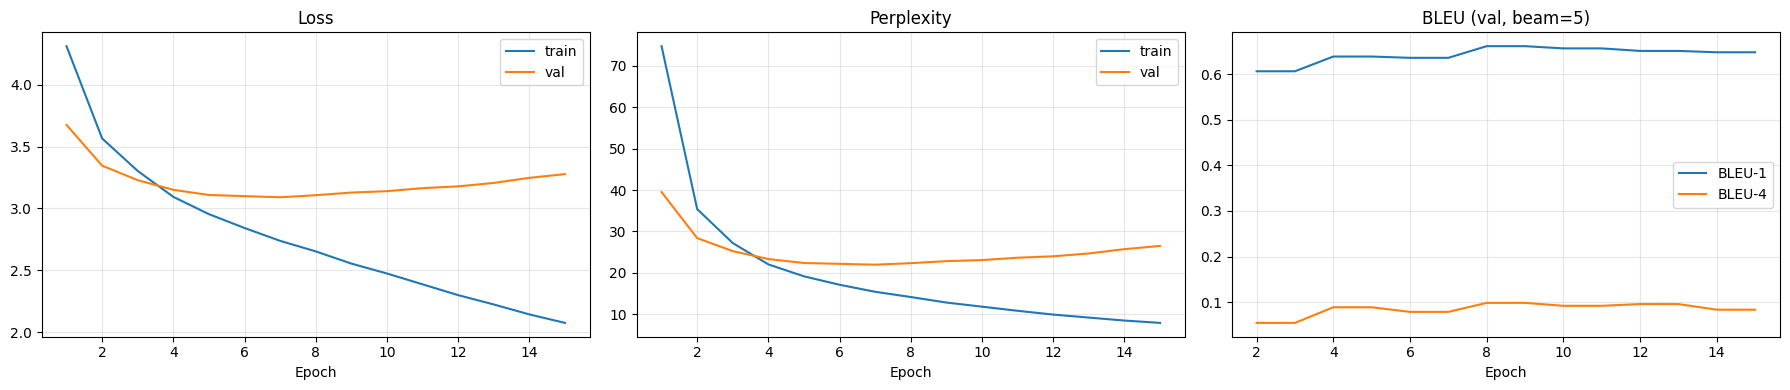

In [16]:
ep = range(1, len(train_losses)+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(ep, train_losses, label="train"); axes[0].plot(ep, val_losses, label="val")
axes[0].set(title="Loss", xlabel="Epoch"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(ep, [math.exp(min(l,10)) for l in train_losses], label="train")
axes[1].plot(ep, [math.exp(min(l,10)) for l in val_losses],   label="val")
axes[1].set(title="Perplexity", xlabel="Epoch"); axes[1].legend(); axes[1].grid(alpha=.3)

axes[2].plot(ep, bleu1s, label="BLEU-1"); axes[2].plot(ep, bleu4s, label="BLEU-4")
axes[2].set(title=f"BLEU (val, beam={BEAM_WIDTH})", xlabel="Epoch"); axes[2].legend(); axes[2].grid(alpha=.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / "curves.png", dpi=150)
plt.show()


## 17 · Save Final Artifacts

Saves the final weights, `config.json`, and vocab, and backs everything up to Drive.

In [17]:
import shutil

torch.save(_encoder.state_dict(), MODEL_DIR / "encoder_final.pth")
torch.save(_decoder.state_dict(), MODEL_DIR / "decoder_final.pth")

cfg = dict(
    encoder="efficientnet_b4_singlescale", proj_dim=PROJ_DIM,
    decoder="transformer", embed_size=EMBED_SIZE,
    n_heads=N_HEADS, n_layers=N_LAYERS, ffn_dim=FFN_DIM,
    dropout=DROPOUT, vocab_size=len(vocab), max_seq_len=MAX_SEQ_LEN,
    beam_width=BEAM_WIDTH, length_penalty=LENGTH_PENALTY,
    best_val_loss=best_val,
    final_bleu1=bleu1s[-1] if bleu1s else None,
    final_bleu4=bleu4s[-1] if bleu4s else None,
    n_gpus=N_GPUS, grad_accum_steps=GRAD_ACCUM_STEPS,
    label_smoothing=LABEL_SMOOTHING, weight_decay=WEIGHT_DECAY,
    best_bleu4=best_bleu4,
)
with open(MODEL_DIR / "config.json", "w") as f:
    json.dump(cfg, f, indent=2)

if DRIVE_DIR:
    for fname in ["encoder_final.pth", "decoder_final.pth", "vocab.pkl", "config.json"]:
        src = MODEL_DIR / fname
        if src.exists():
            shutil.copy(src, Path(DRIVE_DIR) / fname)
    print(f"All artifacts backed up to Drive: {DRIVE_DIR}")

print("Saved locally:")
for p in sorted(MODEL_DIR.iterdir()):
    print(f"  {p.name}  {p.stat().st_size/1024:.1f} KB")


Saved locally:
  config.json  0.5 KB
  curves.png  88.8 KB
  decoder_best.pth  42789.3 KB
  decoder_best_bleu.pth  42789.5 KB
  decoder_epoch05_periodic.pth  42789.9 KB
  decoder_epoch10_periodic.pth  42789.9 KB
  decoder_epoch15_periodic.pth  42789.9 KB
  decoder_final.pth  42789.3 KB
  encoder_best.pth  72884.4 KB
  encoder_best_bleu.pth  72888.1 KB
  encoder_epoch05_periodic.pth  72893.5 KB
  encoder_epoch10_periodic.pth  72893.5 KB
  encoder_epoch15_periodic.pth  72893.5 KB
  encoder_final.pth  72885.1 KB
  training_state.json  1.3 KB
  vocab.pkl  96.6 KB


## 18 · Inference Demo

Loads the **best-BLEU** checkpoint and captions validation images plus your own uploads, so you can inspect caption quality qualitatively (not just by BLEU).

Loading encoder: encoder_best_bleu.pth
Loading decoder: decoder_best_bleu.pth


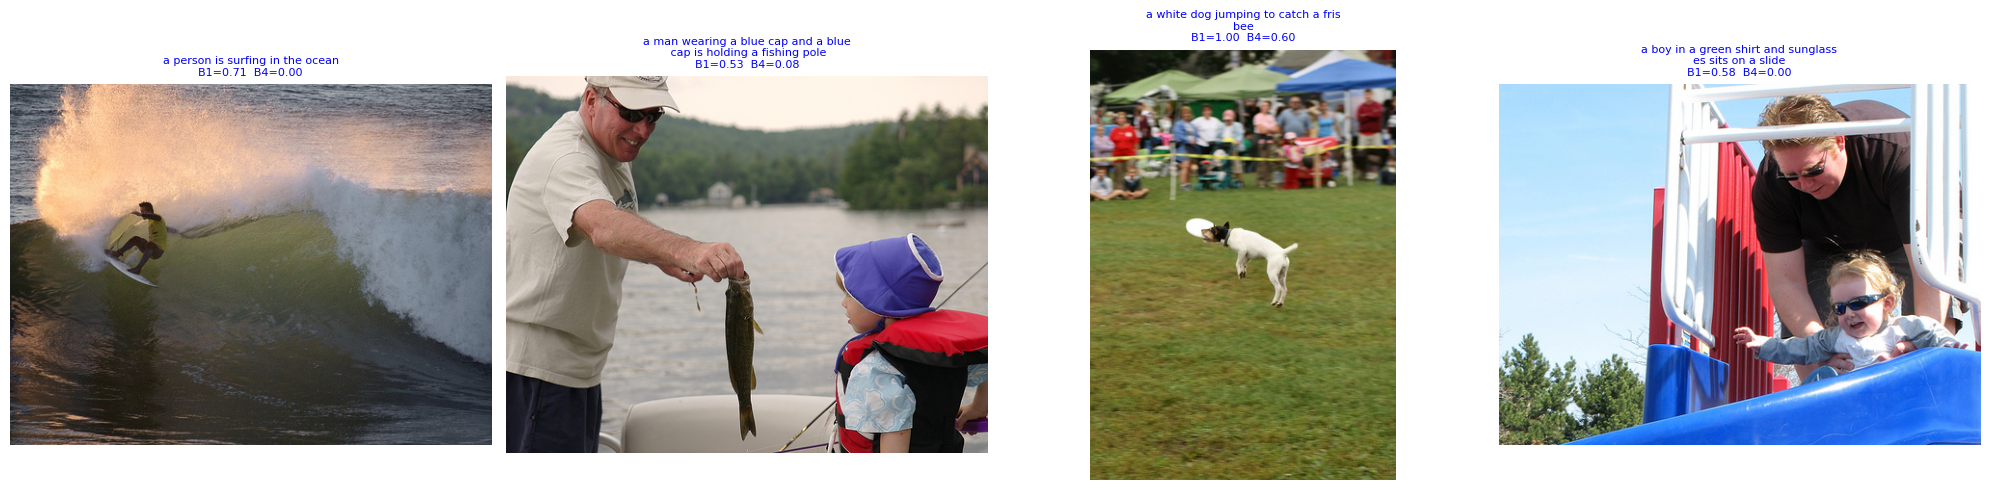


Upload your own image and generate a caption:


In [25]:
import io
import random
import matplotlib.pyplot as plt
import ipywidgets as widgets

from PIL import Image
from IPython.display import display, clear_output


# ============================================================
# 1. LOAD THE BEST CHECKPOINT FOR INFERENCE
# ============================================================

_bleu_enc = MODEL_DIR / "encoder_best_bleu.pth"
_bleu_dec = MODEL_DIR / "decoder_best_bleu.pth"

_enc_ckpt = (
    _bleu_enc
    if _bleu_enc.exists()
    else MODEL_DIR / "encoder_best.pth"
)

_dec_ckpt = (
    _bleu_dec
    if _bleu_dec.exists()
    else MODEL_DIR / "decoder_best.pth"
)

print(f"Loading encoder: {_enc_ckpt.name}")
print(f"Loading decoder: {_dec_ckpt.name}")

_encoder.load_state_dict(
    torch.load(
        _enc_ckpt,
        map_location=DEVICE,
        weights_only=True
    )
)

_decoder.load_state_dict(
    torch.load(
        _dec_ckpt,
        map_location=DEVICE,
        weights_only=True
    )
)

_encoder.eval()
_decoder.eval()


# ============================================================
# 2. CAPTION-GENERATION FUNCTION
# ============================================================

def caption_image(img):
    """
    Generate a caption for one PIL image.
    """

    image_tensor = (
        val_transform(img.convert("RGB"))
        .unsqueeze(0)
        .to(DEVICE)
    )

    with torch.no_grad():
        with torch.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        ):
            visual_features = _encoder(image_tensor)

            tokens = _decoder.generate_beam(
                visual_features,
                vocab,
                BEAM_WIDTH,
                length_penalty=LENGTH_PENALTY
            )

    return tokens


# ============================================================
# 3. AUTOMATICALLY CHOOSE RANDOM VALIDATION IMAGES
# ============================================================

sample_imgs = val_df["image"].unique().tolist()
random.shuffle(sample_imgs)
sample_imgs = sample_imgs[:4]

fig, axes = plt.subplots(
    1,
    len(sample_imgs),
    figsize=(20, 5)
)

# Prevent an error if only one image is selected
if len(sample_imgs) == 1:
    axes = [axes]

for ax, image_name in zip(axes, sample_imgs):

    image_path = IMG_DIR / image_name

    with Image.open(image_path) as opened_image:
        image = opened_image.convert("RGB").copy()

    generated_tokens = caption_image(image)

    reference_captions = val_df[
        val_df["image"] == image_name
    ]["caption"].tolist()

    bleu_scores = corpus_bleu(
        [generated_tokens],
        [[caption.split() for caption in reference_captions]]
    )

    generated_caption = " ".join(generated_tokens)

    # Wrap caption text into shorter lines
    wrapped_caption = "\n".join(
        generated_caption[i:i + 35]
        for i in range(
            0,
            min(len(generated_caption), 70),
            35
        )
    )

    ax.imshow(image)
    ax.axis("off")

    ax.set_title(
        wrapped_caption
        + f"\nB1={bleu_scores['bleu1']:.2f}"
        + f"  B4={bleu_scores['bleu4']:.2f}",
        fontsize=8,
        color="blue"
    )

plt.tight_layout()

plt.savefig(
    MODEL_DIR / "samples.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# 4. MANUAL IMAGE-UPLOAD BUTTON FOR KAGGLE
# ============================================================

print("\nUpload your own image and generate a caption:")

_uploader = widgets.FileUpload(
    accept="image/*",
    multiple=True,
    description="Choose images"
)

_caption_button = widgets.Button(
    description="Generate captions",
    button_style="primary",
    icon="camera"
)

_upload_output = widgets.Output()

display(
    widgets.VBox([
        _uploader,
        _caption_button,
        _upload_output
    ])
)


# ============================================================
# 5. SUPPORT BOTH IPYWIDGETS 7 AND IPYWIDGETS 8
# ============================================================

def extract_uploaded_files(upload_value):
    """
    Convert FileUpload.value into:
        (filename, raw_bytes)

    Supports both ipywidgets 7 and ipywidgets 8.
    """

    # ipywidgets 7:
    # {
    #   "image.jpg": {
    #       "content": bytes,
    #       ...
    #   }
    # }
    if isinstance(upload_value, dict):

        for filename, file_info in upload_value.items():

            content = file_info["content"]

            if hasattr(content, "tobytes"):
                content = content.tobytes()
            else:
                content = bytes(content)

            yield filename, content

    # ipywidgets 8:
    # (
    #   {
    #       "name": "image.jpg",
    #       "content": memoryview(...),
    #       ...
    #   },
    # )
    else:

        for file_info in upload_value:

            filename = file_info["name"]
            content = file_info["content"]

            if hasattr(content, "tobytes"):
                content = content.tobytes()
            else:
                content = bytes(content)

            yield filename, content


# ============================================================
# 6. GENERATE CAPTIONS FOR MANUALLY UPLOADED IMAGES
# ============================================================

def process_uploaded_images(_):

    with _upload_output:

        clear_output(wait=True)

        if not _uploader.value:
            print("Choose at least one image first.")
            return

        uploaded_files = list(
            extract_uploaded_files(_uploader.value)
        )

        print(
            f"Processing {len(uploaded_files)} "
            f"uploaded image(s)...\n"
        )

        for filename, raw_bytes in uploaded_files:

            try:

                with io.BytesIO(raw_bytes) as buffer:
                    image = (
                        Image.open(buffer)
                        .convert("RGB")
                        .copy()
                    )

                generated_tokens = caption_image(image)
                generated_caption = " ".join(
                    generated_tokens
                )

                wrapped_caption = "\n".join(
                    generated_caption[i:i + 55]
                    for i in range(
                        0,
                        len(generated_caption),
                        55
                    )
                )

                fig, ax = plt.subplots(
                    figsize=(7, 6)
                )

                ax.imshow(image)
                ax.axis("off")

                ax.set_title(
                    wrapped_caption,
                    fontsize=11,
                    color="blue"
                )

                plt.tight_layout()
                plt.show()
                plt.close(fig)

                print(f"File: {filename}")
                print(
                    f"Generated caption: "
                    f"{generated_caption}"
                )
                print("-" * 70)

            except Exception as error:

                print(
                    f"Could not process {filename}: "
                    f"{type(error).__name__}: {error}"
                )


_caption_button.on_click(process_uploaded_images)